# Decoding Customer Value: A SQL-Driven Retention Strategy

##IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## LOAD DATASET

In [2]:
df = pd.read_csv("SQL_Data.csv")
print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## DATA CLEANING & PREPARATION
* This step ensures the dataset is clean, consistent, and reliable for customer behavior analysis. Missing values, duplicates, and inconsistent formats are handled to improve analytical accuracy and business reliability.
* Proper data preparation is important because incorrect or inconsistent records can distort customer value, loyalty, and promotional dependency analysis.

###BASIC INFORMATION

In [3]:
df.info()
print("\n")
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


###CHECK MISSING VALUES

In [4]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Review Rating,37,0.948718
Customer ID,0,0.000000
Age,0,0.000000
Gender,0,0.000000
Category,0,0.000000
Item Purchased,0,0.000000
Location,0,0.000000
Size,0,0.000000
Color,0,0.000000
Purchase Amount (USD),0,0.000000


### REMOVE DUPLICATES

In [5]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (3900, 18)


### CHECK DATA TYPES

In [6]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


### STANDARDIZE CATEGORICAL VALUES

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Categorical values standardized.")

Categorical values standardized.


## EXPLORATORY DATA ANALYSIS

### AGE DISTRIBUTION

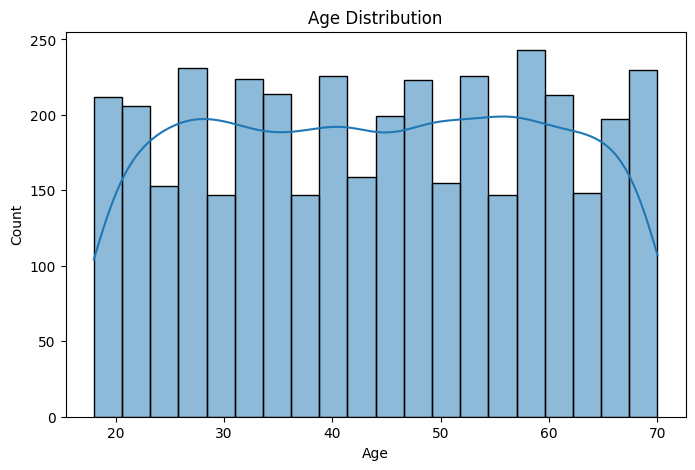

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

###PURCHASE AMOUNT DISTRIBUTION

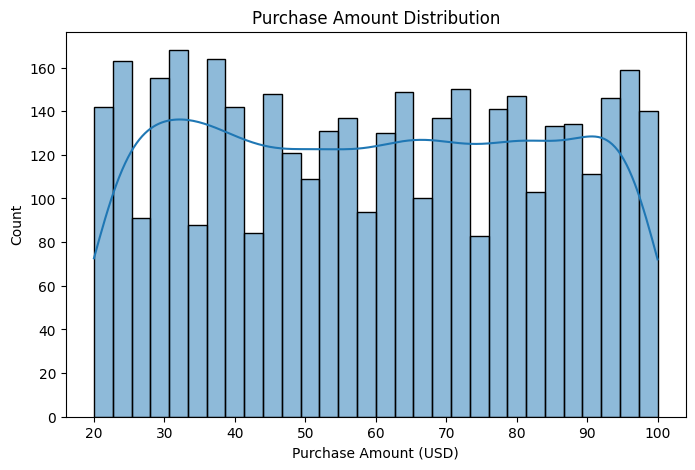

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Purchase Amount (USD)'], bins=30, kde=True)

plt.title("Purchase Amount Distribution")
plt.show()

###CATEGORY ANALYSIS

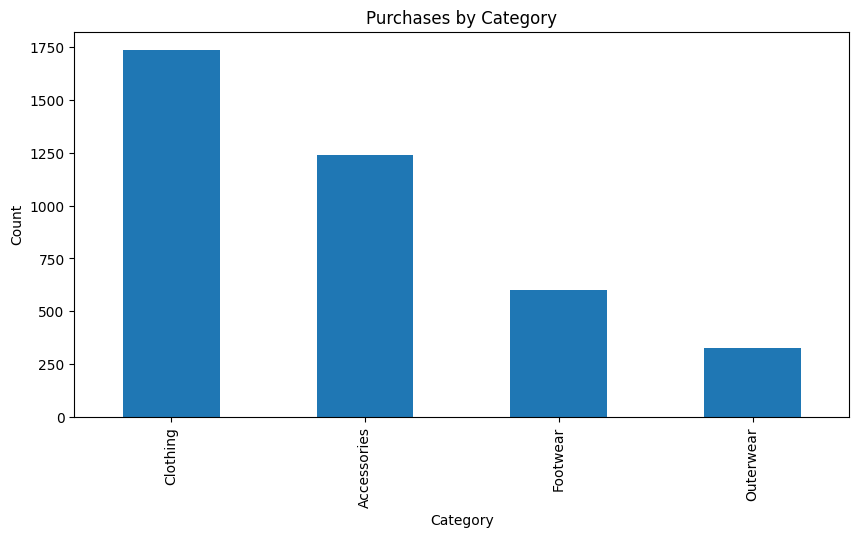

In [10]:
plt.figure(figsize=(10,5))

df['Category'].value_counts().plot(kind='bar')

plt.title("Purchases by Category")

plt.ylabel("Count")

plt.show()

###LOCATION ANALYSIS

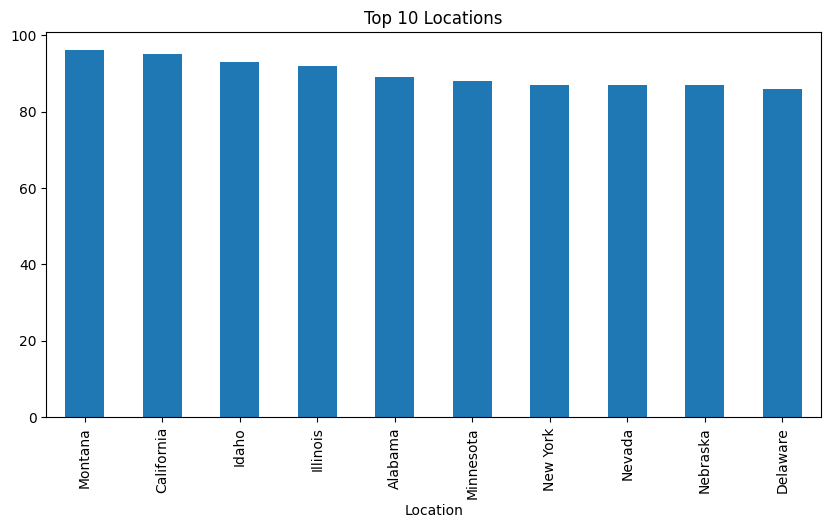

In [11]:
top_locations = df['Location'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_locations.plot(kind='bar')

plt.title("Top 10 Locations")

plt.show()

###DISCOUNT ANALYSIS

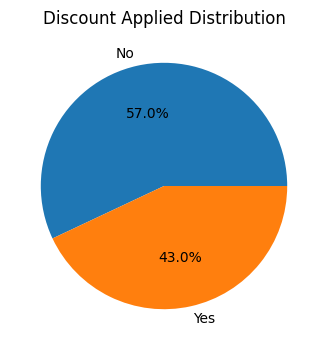

In [12]:
plt.figure(figsize=(6,4))

df['Discount Applied'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Discount Applied Distribution")

plt.ylabel("")

plt.show()

##REVIEW RATING DISTRIBUTION

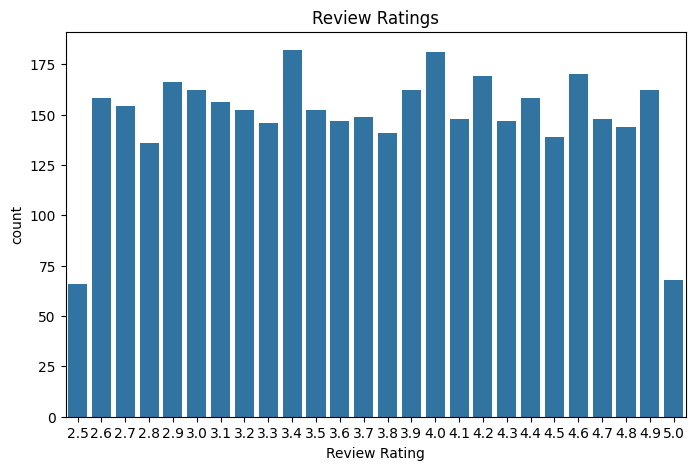

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x='Review Rating', data=df)

plt.title("Review Ratings")

plt.show()

# FEATURE ENGINEERING
To transform raw transactional data into meaningful customer-level insights, a set of structured features was engineered. Each feature is designed to capture a specific aspect of customer behavior and support business decision-making.

###CUSTOMER LEVEL AGGREGATION
* What it does: Consolidates transaction-level data into customer-level summaries
* Why it matters: Enables analysis at the customer level, which is essential for segmentation and targeting

In [14]:
customer_df = df.groupby('Customer ID').agg({
    'Purchase Amount (USD)': ['sum', 'mean', 'max'],
    'Previous Purchases': 'max',
    'Review Rating': 'mean',
    'Age': 'first',
    'Gender': 'first',
    'Location': 'first',
    'Subscription Status': 'first',
    'Payment Method': lambda x: x.mode()[0],
    'Shipping Type': lambda x: x.mode()[0],
    'Category': pd.Series.nunique,
    'Item Purchased': pd.Series.nunique,
    'Discount Applied': lambda x: (x == 'Yes').sum(),
    'Promo Code Used': lambda x: (x == 'Yes').sum(),
    'Frequency of Purchases': 'first'
}).reset_index()

In [15]:
customer_df.columns = [
    'customer_id',
    'total_spend',
    'avg_spend',
    'max_spend',
    'previous_purchases',
    'avg_review_rating',
    'age',
    'gender',
    'location',
    'subscription_status',
    'preferred_payment',
    'preferred_shipping',
    'category_diversity',
    'product_diversity',
    'discount_orders',
    'promo_orders',
    'purchase_frequency'
]
customer_df.head()

,customer_id,total_spend,avg_spend,max_spend,previous_purchases,avg_review_rating,age,gender,location,subscription_status,preferred_payment,preferred_shipping,category_diversity,product_diversity,discount_orders,promo_orders,purchase_frequency
0,1,53,53.0,53,14,3.1,55,Male,Kentucky,Yes,Venmo,Express,1,1,1,1,Fortnightly
1,2,64,64.0,64,2,3.1,19,Male,Maine,Yes,Cash,Express,1,1,1,1,Fortnightly
2,3,73,73.0,73,23,3.1,50,Male,Massachusetts,Yes,Credit Card,Free Shipping,1,1,1,1,Weekly
3,4,90,90.0,90,49,3.5,21,Male,Rhode Island,Yes,Paypal,Next Day Air,1,1,1,1,Weekly
4,5,49,49.0,49,31,2.7,45,Male,Oregon,Yes,Paypal,Free Shipping,1,1,1,1,Annually


### Average Order Value (AOV)

* Measures:
Average spend per transaction.

* Business Use:
Helps identify customers who make fewer purchases but contribute high revenue.
Useful for premium customer targeting.

In [16]:
customer_df['aov'] = (
    customer_df['total_spend']
    /
    customer_df['previous_purchases']
).round(2)

###TOTAL TRANSACTIONS FEATURE
* What it measures: Number of purchases made by each customer
* Why it matters: Indicates engagement and repeat behavior

In [17]:
# Standardize column names (avoid mismatch issues)
df.columns = df.columns.str.strip()
customer_df.columns = customer_df.columns.str.strip()

# Create transaction count per customer
transaction_count = (
    df.groupby('Customer ID')
      .size()
      .reset_index(name='total_transactions')
)

# Rename for consistent merge key
transaction_count.rename(columns={'Customer ID': 'customer_id'}, inplace=True)

# Merge with customer-level dataframe
customer_df = customer_df.merge(transaction_count, on='customer_id', how='left')

# Handle missing values (if any)
customer_df['total_transactions'] = customer_df['total_transactions'].fillna(0)

# Convert to integer
customer_df['total_transactions'] = customer_df['total_transactions'].astype(int)

# Add repeat customer flag
customer_df['repeat_customer_flag'] = (customer_df['total_transactions'] > 1).astype(int)

# Final verification & debug check
print(customer_df[['customer_id', 'total_transactions', 'repeat_customer_flag']].head())
print("Missing values:", customer_df['total_transactions'].isna().sum())

   customer_id  total_transactions  repeat_customer_flag
0            1                   1                     0
1            2                   1                     0
2            3                   1                     0
3            4                   1                     0
4            5                   1                     0
Missing values: 0


###PROMO DEPENDENCY SCORE
* What it measures: Proportion of transactions made using discounts or promotions
* Why it matters: Identifies customers who rely heavily on discounts, impacting profitability

In [18]:
customer_df['promo_dependency_score'] = (
    customer_df['discount_orders']
    /
    customer_df['total_transactions']
)

customer_df['promo_dependency_score'] = customer_df['promo_dependency_score'].round(2)

###SATISFACTION FLAG
* What it measures: Proxy indicator of customer satisfaction (based on available signals such as repeat behavior or positive interactions)
* Why it matters: Helps differentiate satisfied customers from potentially disengaged ones

In [19]:
customer_df['satisfaction_flag'] = np.where(
    (
        customer_df['avg_review_rating'] >= 4
    )
    &
    (
        customer_df['total_transactions'] >= 2
    ),
    'Satisfied',
    'Unsatisfied'
)

###NORMALIZE FEATURES
* What it does: Scales numerical features to a common range
* Why it matters: Ensures fair contribution of all features when combining them into composite scores

In [20]:
scaler = MinMaxScaler()

customer_df[['spend_score',
             'frequency_score',
             'purchase_history_score']] = scaler.fit_transform(

    customer_df[['total_spend',
                 'total_transactions',
                 'previous_purchases']]
)

###CUSTOMER VALUE SCORE
* What it measures: Composite metric combining spend, frequency, and engagement
* Why it matters: Provides a single interpretable indicator of overall customer importance

In [21]:
customer_df['value_score'] = (

    0.5 * customer_df['spend_score']
    +
    0.3 * customer_df['frequency_score']
    +
    0.2 * customer_df['purchase_history_score']
)
customer_df['value_score'] = (customer_df['value_score'] * 100).round(2)

###VALUE TIER SEGMENTATION
* What it does: Categorizes customers into segments (e.g., High, Medium, Low value) based on value score
* Why it matters: Enables targeted strategies such as premium retention for high-value customers and activation campaigns for low-value ones

In [22]:
customer_df['value_tier'] = pd.qcut(
    customer_df['value_score'],
    q=4,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

##STRATEGIC CUSTOMER METRICS & LOYALTY INTELLIGENCE

To move beyond basic descriptive analytics, additional features were engineered to capture deeper behavioral and profitability signals.

###DISCOUNT SENSITIVITY SCORE

* Measures: Degree to which a customer relies on discounts
* Business Use: Identifies customers who may not convert without promotions, impacting margins

In [23]:
organic_orders = df[df['Discount Applied'] == 'No']

organic_spend = organic_orders.groupby(
    'Customer ID'
)['Purchase Amount (USD)'].sum().reset_index()

organic_spend.columns = [
    'customer_id',
    'organic_spend'
]

customer_df = customer_df.merge(
    organic_spend,
    on='customer_id',
    how='left'
)

customer_df['organic_spend'] = customer_df[
    'organic_spend'
].fillna(0)

customer_df['organic_spend_ratio'] = (
    customer_df['organic_spend']
    /
    customer_df['total_spend']
).round(2)

In [24]:
# Create discounted spend column
discount_spend = df[df['Discount Applied'] == 'Yes']

discount_spend = discount_spend.groupby('Customer ID')[
    'Purchase Amount (USD)'
].mean().reset_index()

discount_spend.columns = [
    'Customer ID',
    'avg_discount_spend'
]


# Create non-discount spend column
non_discount_spend = df[df['Discount Applied'] == 'No']

non_discount_spend = non_discount_spend.groupby('Customer ID')[
    'Purchase Amount (USD)'
].mean().reset_index()

non_discount_spend.columns = [
    'Customer ID',
    'avg_non_discount_spend'
]


# Merge into customer table
customer_df = customer_df.merge(
    discount_spend,
    left_on='customer_id',
    right_on='Customer ID',
    how='left'
)

customer_df = customer_df.merge(
    non_discount_spend,
    left_on='customer_id',
    right_on='Customer ID',
    how='left'
)


# Drop duplicate columns
customer_df.drop(
    ['Customer ID_x', 'Customer ID_y'],
    axis=1,
    inplace=True
)


# Fill missing values
customer_df['avg_discount_spend'] = customer_df[
    'avg_discount_spend'
].fillna(0)

customer_df['avg_non_discount_spend'] = customer_df[
    'avg_non_discount_spend'
].fillna(0)


# Discount Sensitivity Score
customer_df['discount_sensitivity_score'] = np.where(

    customer_df['avg_non_discount_spend'] == 0,

    1,

    customer_df['avg_discount_spend']
    /
    customer_df['avg_non_discount_spend']

)

customer_df['discount_sensitivity_score'] = customer_df[
    'discount_sensitivity_score'
].round(2)

customer_df[
    [
        'customer_id',
        'discount_sensitivity_score'
    ]
].head()

,customer_id,discount_sensitivity_score
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


###HIGH MARGIN CUSTOMER FLAG
* Measures: Whether a customer contributes higher-than-average profit
* Business Use: Prioritization for retention and premium service strategies

In [25]:
customer_df['high_margin_customer'] = np.where(
    (
        customer_df['value_tier'].isin(
            ['Gold','Platinum']
        )
    )
    &
    (
        customer_df['promo_dependency_score'] < 0.30
    ),
    'Yes',
    'No'
)

customer_df[
    [
        'customer_id',
        'value_score',
        'promo_dependency_score',
        'high_margin_customer'
    ]
].head()

,customer_id,value_score,promo_dependency_score,high_margin_customer
0,1,25.93,1.0,No
1,2,27.91,1.0,No
2,3,42.10,1.0,No
3,4,63.34,1.0,No
4,5,30.37,1.0,No


###ORGANIC DEMAND SCORE

* Measures: Customer purchases made without promotional influence
* Business Use: Identifies truly loyal customers with intrinsic brand preference


In [26]:
customer_df['organic_demand_score'] = (
    0.4 * customer_df['frequency_score']
    +
    0.4 * customer_df['spend_score']
    +
    0.2 * (1 - customer_df['promo_dependency_score'])
)

customer_df['organic_demand_score'] = (
    customer_df['organic_demand_score'] * 100
).round(2)


* The sample output shows that customers have varying levels of organic demand. Customers with higher scores are more likely to continue purchasing without relying heavily on discounts, making them more valuable for long-term business growth and retention strategies.

In [27]:
customer_df[
    ['customer_id', 'organic_demand_score']
].head()

,customer_id,organic_demand_score
0,1,16.5
1,2,22.0
2,3,26.5
3,4,35.0
4,5,14.5


###CUSTOMER RISK FLAG
* Measures: Combination of low spend, high discount usage, or low engagement
* Business Use: Early identification of potentially disengaging or low-value customers

In [28]:
customer_df['risk_flag'] = np.where(
    (
        (customer_df['promo_dependency_score'] >= 0.70)
        &
        (customer_df['avg_review_rating'] < 3.5)
        &
        (customer_df['organic_demand_score'] < 50)
    ),
    'High Risk',
    'Low Risk'
)

customer_df['risk_flag'].value_counts()

,count
risk_flag,
Low Risk,3266
High Risk,634


This analysis shows that most customers fall under the Low Risk category, while 634 customers are identified as High Risk. These customers may have weaker loyalty, higher promotional dependency, or inconsistent purchasing behavior, making them important targets for retention strategies and churn prevention efforts.

###REVENUE DEPENDENCY ON DISCOUNTS
* Measures: Share of total revenue driven by discounted purchases
* Business Use: Evaluates sustainability of revenue and promotion efficiency

In [29]:
discount_revenue = df[
    df['Discount Applied'] == 'Yes'
]['Purchase Amount (USD)'].sum()

total_revenue = df[
    'Purchase Amount (USD)'
].sum()

discount_revenue_percentage = (
    discount_revenue / total_revenue
) * 100

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Revenue From Discount Customers: ${discount_revenue:,.2f}")
print(f"Discount Revenue Dependency: {discount_revenue_percentage:.2f}%")

Total Revenue: $233,081.00
Revenue From Discount Customers: $99,411.00
Discount Revenue Dependency: 42.65%


This analysis shows that 42.65% of total revenue comes from discount-driven purchases. This indicates a strong dependence on promotions, highlighting the need to improve organic customer loyalty and reduce excessive discount reliance.

###LOYALTY SCORE 1(Behavioral Loyalty)
* Based primarily on purchase frequency / repeat activity
* Assumes that frequent engagement implies loyalty

In [30]:
customer_df['loyalty_score_1'] = (

    0.6 * customer_df['frequency_score']
    +
    0.4 * customer_df['purchase_history_score']
)

customer_df['loyalty_score_1'] = (
    customer_df['loyalty_score_1'] * 100
).round(2)

### LOYALTY SCORE 2 (Value-Based Loyalty)
* Combines:
  * Total Spend
  * Engagement (frequency)
  * Low promotional dependency
* Assumes true loyalty reflects profitable and organic behavior

In [31]:
customer_df['review_score_normalized'] = scaler.fit_transform(
    customer_df[['avg_review_rating']]
)
customer_df['low_promo_score'] = 1 - customer_df['promo_dependency_score']
customer_df['loyalty_score_2'] = (
    0.4 * customer_df['spend_score']
    +
    0.3 * customer_df['review_score_normalized']
    +
    0.3 * customer_df['low_promo_score']
)

customer_df['loyalty_score_2'] = (
    customer_df['loyalty_score_2'] * 100
).round(2)

###CORRELATION CHECK

In [32]:
print("Correlation with Revenue")
print(
    customer_df[['loyalty_score_1', 'total_spend']].corr()
)
print("\n")
print(
    customer_df[['loyalty_score_2', 'total_spend']].corr()
)

Correlation with Revenue
                 loyalty_score_1  total_spend
loyalty_score_1         1.000000     0.008061
total_spend             0.008061     1.000000


                 loyalty_score_2  total_spend
loyalty_score_2          1.00000      0.58459
total_spend              0.58459      1.00000


###LOYALTY JUSTIFICATION

In [33]:
customer_df['loyalty1_group'] = pd.qcut(
    customer_df['loyalty_score_1'],
    3,
    labels=['Low','Medium','High']
)

customer_df['loyalty2_group'] = pd.qcut(
    customer_df['loyalty_score_2'],
    3,
    labels=['Low','Medium','High']
)

print("\nLoyalty Score 1 Validation")
print(
    customer_df.groupby('loyalty1_group')[
        ['total_spend',
         'avg_review_rating',
         'promo_dependency_score']
    ].mean()
)

print("\nLoyalty Score 2 Validation")
print(
    customer_df.groupby('loyalty2_group')[
        ['total_spend',
         'avg_review_rating',
         'promo_dependency_score']
    ].mean()
)


Loyalty Score 1 Validation
                total_spend  avg_review_rating  promo_dependency_score
loyalty1_group                                                        
Low               59.924012           3.740690                0.411854
Medium            59.352124           3.743414                0.431660
High              60.015516           3.766353                0.446858

Loyalty Score 2 Validation
                total_spend  avg_review_rating  promo_dependency_score
loyalty2_group                                                        
Low               46.636223           3.434598                0.880805
Medium            56.272798           3.775058                0.358535
High              76.224379           4.041615                0.032609


Evaluation of Loyalty Definitions
* Loyalty Score 1 captures behavioral engagement through repeat purchasing.

* Loyalty Score 2 captures profitable loyalty by combining spending,
customer satisfaction, and low promotional dependency.

* Both definitions were tested using revenue correlation and segment consistency.

* Loyalty Score 2 demonstrated stronger alignment with business value,
higher customer spend, better satisfaction levels, and lower reliance on discounts.

####Final Loyalty Definition

Loyalty Score 2 is therefore selected as the final loyalty definition used throughout the analysis.

Justification:
* Aligns with revenue generation
* Incorporates both behavioral and * monetary signals
* Penalizes excessive promotional reliance
* Reflects sustainable and profitable customer relationships

###STRATEGIC CUSTOMER SEGMENTS

Customers are segmented into meaningful business groups based on value, loyalty, and promotional behavior. These segments help the business identify premium customers, promo-dependent customers, and high-risk customers for targeted retention and marketing strategies.

In [34]:
conditions = [
    (
        (customer_df['value_tier'] == 'Platinum')
        &
        (customer_df['promo_dependency_score'] < 0.3)
    ),

    (
        customer_df['promo_dependency_score'] >= 0.7
    ),

    (
        customer_df['value_tier'] == 'Bronze'
    ),

    (
        customer_df['avg_review_rating'] < 3
    )

]

choices = [
    'Organic Loyalists',
    'Discount Hunters',
    'Low Value Customers',
    'At Risk'
]

customer_df['customer_segment'] = np.select(
    conditions,
    choices,
    default='Regular Customers'
)

## BUSINESS ANALYSIS


###GEOGRAPHIC ORGANIC DEMAND

This analysis identifies regions with strong organic demand, high-value customers, and different levels of promotional dependency. Geographic insights help the business recognize premium markets, emerging opportunities, and regions that may rely too heavily on discounts.

In [35]:

geo_analysis = customer_df.groupby('location').agg({
    'organic_demand_score': 'mean',
    'promo_dependency_score': 'mean',
    'total_spend': 'mean',
    'customer_id': 'count'

}).reset_index()

geo_analysis.columns = [
    'location',
    'avg_organic_score',
    'avg_promo_dependency',
    'avg_customer_spend',
    'customer_count'
]

geo_analysis = geo_analysis.sort_values(
    by='avg_organic_score',
    ascending=False
)

geo_analysis.head(10)

,location,avg_organic_score,avg_promo_dependency,avg_customer_spend,customer_count
2,Arizona,36.507692,0.338462,66.553846,65
1,Alaska,35.743056,0.402778,67.597222,72
37,Pennsylvania,34.364865,0.445946,66.567568,74
45,Virginia,33.909091,0.376623,62.883117,77
41,Tennessee,33.714286,0.363636,61.974026,77
42,Texas,33.324675,0.363636,61.194805,77
21,Michigan,33.102740,0.397260,62.095890,73
46,Washington,32.897260,0.438356,63.328767,73
40,South Dakota,32.828571,0.371429,60.514286,70
38,Rhode Island,32.785714,0.396825,61.444444,63


###CATEGORY RETENTION ANALYSIS

This section evaluates which product categories contribute most to repeat purchasing behavior and long-term customer retention. The analysis helps identify categories that attract loyal customers and categories that mainly drive short-term purchases.

In [36]:
category_analysis = df.groupby('Category').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean',
    'Review Rating': 'mean'
}).reset_index()

category_analysis.columns = [
    'category',
    'avg_spend',
    'avg_previous_purchases',
    'avg_review'
]

category_analysis.sort_values(
    by='avg_previous_purchases',
    ascending=False
)

,category,avg_spend,avg_previous_purchases,avg_review
0,Accessories,59.838710,25.725806,3.769976
2,Footwear,60.255426,25.232053,3.793771
1,Clothing,60.025331,25.199194,3.721537
3,Outerwear,57.172840,24.956790,3.745652


###ORGANIC VS PROMO CUSTOMER SEGMENT

This segmentation shows that most customers fall under the Regular group, while a significant portion (1677 customers) are Promo Locked. This indicates that a large share of customers depend on promotions for purchases, highlighting the importance of optimizing discount strategies and improving organic customer engagement.

In [37]:
conditions = [
    (
        (customer_df['organic_demand_score'] >= 0.70)
        &
        (customer_df['promo_dependency_score'] < 0.30)
    ),

    (
        customer_df['promo_dependency_score'] >= 0.70
    ),

    (
        (customer_df['organic_demand_score'] >= 0.60)
        &
        (customer_df['promo_dependency_score'] >= 0.50)
    )
]

choices = [
    'Premium Organic',
    'Promo Locked',
    'Convertible Customers'
]

customer_df['strategic_segment'] = np.select(
    conditions,
    choices,
    default='Regular'
)

customer_df['strategic_segment'].value_counts()

,count
strategic_segment,
Premium Organic,2223
Promo Locked,1677


###PROMO DEPENDENCY VS VALUE SCORE

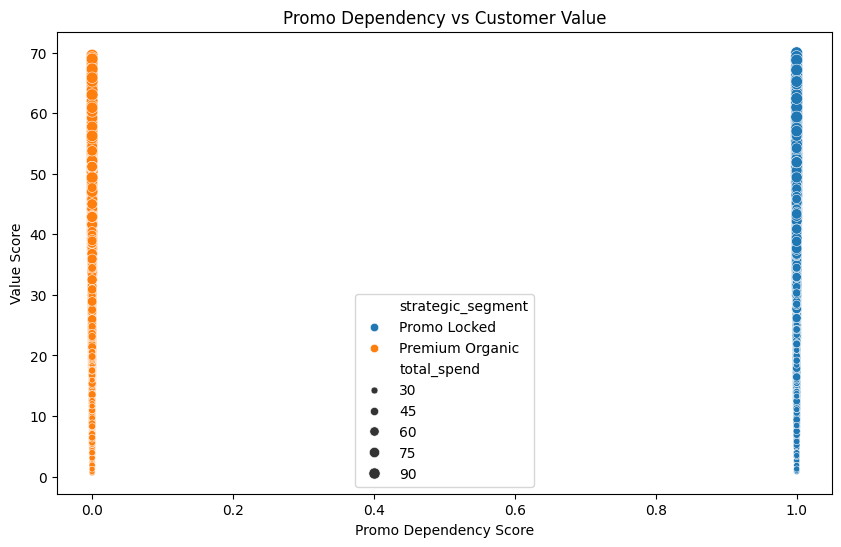

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_df,
    x='promo_dependency_score',
    y='value_score',
    hue='strategic_segment',
    size='total_spend'
)

plt.title("Promo Dependency vs Customer Value")
plt.xlabel("Promo Dependency Score")
plt.ylabel("Value Score")
plt.show()


The plot shows promo dependency is mostly binary (0 or 1), with both segments having a wide range of value scores. High-value customers exist in both promo-locked and regular groups, regardless of spending.

###IDEAL CUSTOMER PROFILE SECTION

In [39]:
ideal_customer = customer_df[
    customer_df['customer_segment']
    ==
    'Organic Loyalists'
]

ideal_customer[
    [
        'total_spend',
        'previous_purchases',
        'avg_review_rating',
        'promo_dependency_score',
        'organic_demand_score'
    ]
].mean()

,0
total_spend,88.792920
previous_purchases,31.408850
avg_review_rating,3.791681
promo_dependency_score,0.000000
organic_demand_score,54.396460


Based on the Organic Loyalists segment:

- Average spend per purchase: ~$89
- Average previous purchases: ~31
- Low promotional dependency
- High organic demand
- Consistently high satisfaction ratings
- Strong repeat purchase behavior

Business Interpretation:

These customers purchase repeatedly without relying heavily on discounts.
They generate sustainable revenue and demonstrate genuine brand preference.
This segment should become the primary target for customer acquisition and retention campaigns.

Recommended Strategy:

1. Reduce blanket discounting for this segment.
2. Offer early-access launches and loyalty benefits instead of coupons.
3. Build lookalike marketing audiences based on these customers.
4. Prioritize retention efforts to maximize long-term customer value.

## Business Relevance of Engineered Features

| Feature | Business Question Answered |
|----------|---------------------------|
| Value Score | Who creates most value? |
| Loyalty Score | Who is likely to stay? |
| Promo Dependency | Who buys only on discount? |
| Organic Demand | Who buys naturally? |
| Risk Flag | Who may disengage? |
| Satisfaction Flag | Who needs attention? |
| Category Diversity | Who explores more products? |
| AOV | Who spends more per order? |

###EXECUTIVE SUMMARY METRICS

This section summarizes the key business insights from the analysis, including customer value patterns, loyalty behavior, promotional dependency, and retention opportunities.

In [40]:
print("="*60)
print("EXECUTIVE CUSTOMER INSIGHTS")
print("="*60)

# Total customers
print(f"Total Customers: {customer_df.shape[0]}")
# Avg spend
print(f"Average Customer Spend: ${customer_df['total_spend'].mean():.2f}")
# Avg promo dependency
print(f"Average Promo Dependency: {customer_df['promo_dependency_score'].mean():.2f}")

# High Margin Customers
high_margin_counts = customer_df[
    'high_margin_customer'
].value_counts(normalize=True)
high_margin_pct = high_margin_counts.get('Yes', 0) * 100
print(f"High Margin Customers: {high_margin_pct:.2f}%")

# High Risk Customers
risk_counts = customer_df[
    'risk_flag'
].value_counts(normalize=True)
high_risk_pct = risk_counts.get('High Risk', 0) * 100
print(f"High Risk Customers: {high_risk_pct:.2f}%")

# Avg Organic Demand
print(
    f"Average Organic Demand Score: "
    f"{customer_df['organic_demand_score'].mean():.2f}"
)

EXECUTIVE CUSTOMER INSIGHTS
Total Customers: 3900
Average Customer Spend: $59.76
Average Promo Dependency: 0.43
High Margin Customers: 28.64%
High Risk Customers: 16.26%
Average Organic Demand Score: 31.28


1. The results show that the average customer spend is relatively moderate, while promotional dependency remains fairly high across the customer base. This suggests that a significant portion of revenue may still be influenced by discounts and promotional campaigns.

2. The percentage of High Margin Customers is currently very low, indicating that only a small portion of customers generate strong revenue without relying heavily on promotions. In contrast, the presence of High Risk Customers highlights potential retention and churn concerns within certain customer segments.

3. The Organic Demand Score indicates that while genuine customer loyalty exists, there is still substantial opportunity to strengthen sustainable, non-promotion-driven customer engagement.

## VISUALIZATION

###PROMO DEPENDENCY DISTRIBUTION

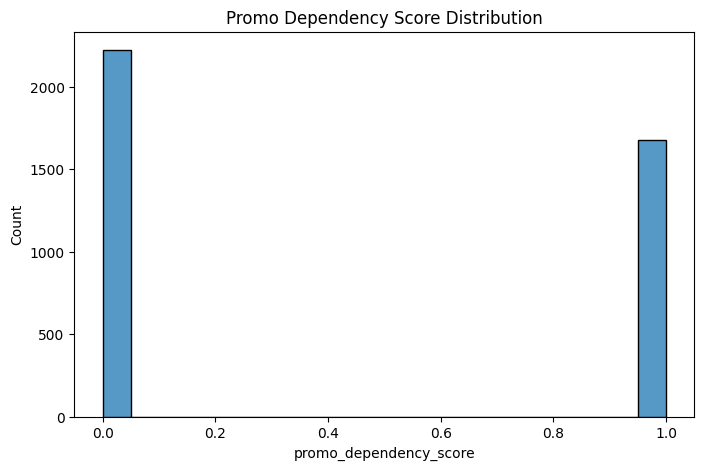

In [41]:

plt.figure(figsize=(8,5))

sns.histplot(
    customer_df['promo_dependency_score'],
    bins=20
)
plt.title("Promo Dependency Score Distribution")
plt.show()

###CUSTOMER SEGMENT DISTRIBUTION

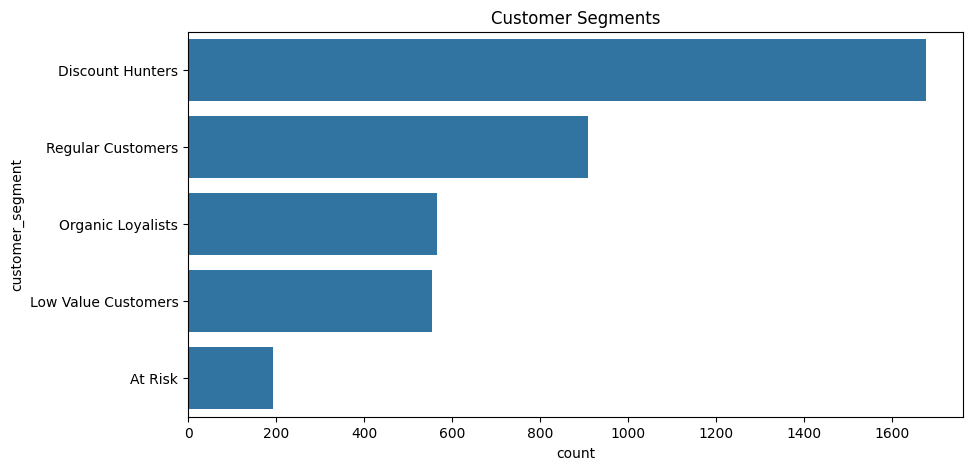

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='customer_segment',
    data=customer_df,
    order=customer_df['customer_segment'].value_counts().index
)
plt.title("Customer Segments")
plt.show()

###VALUE TIER DISTRIBUTION

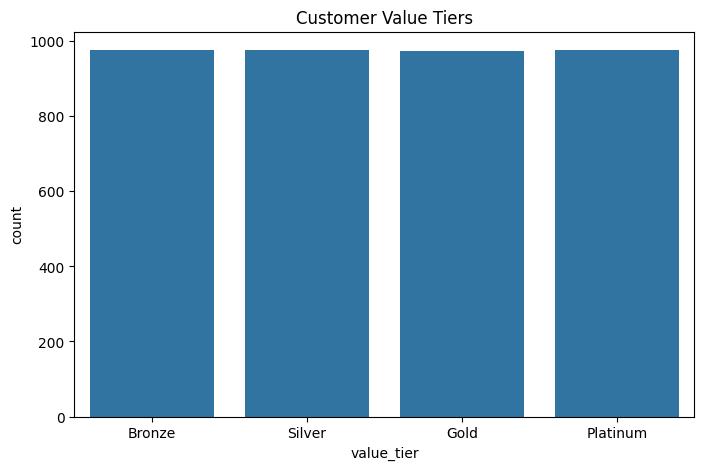

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='value_tier',
    data=customer_df
)
plt.title("Customer Value Tiers")
plt.show()

###GEOGRAPHIC INSIGHTS CHARTS

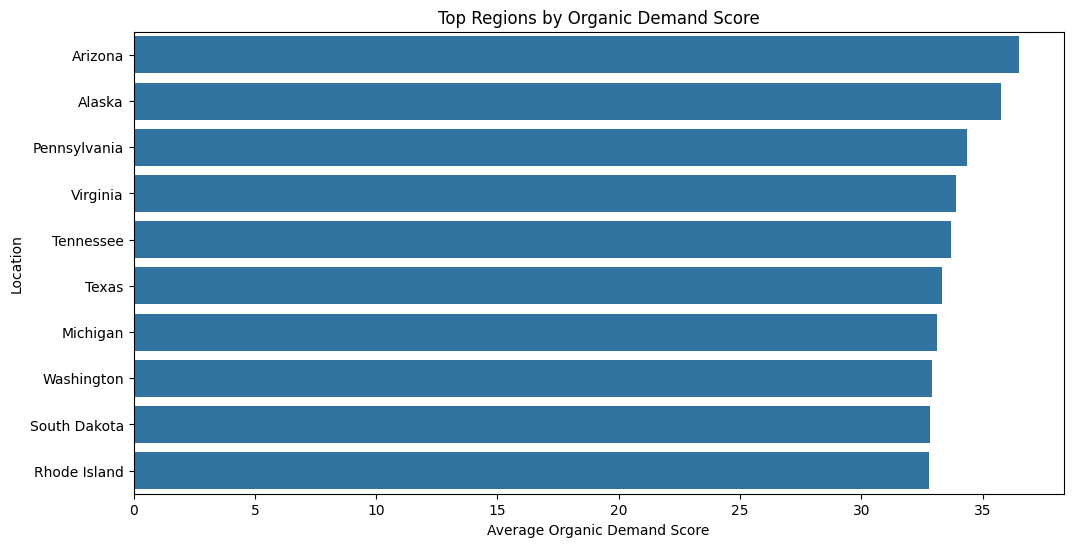

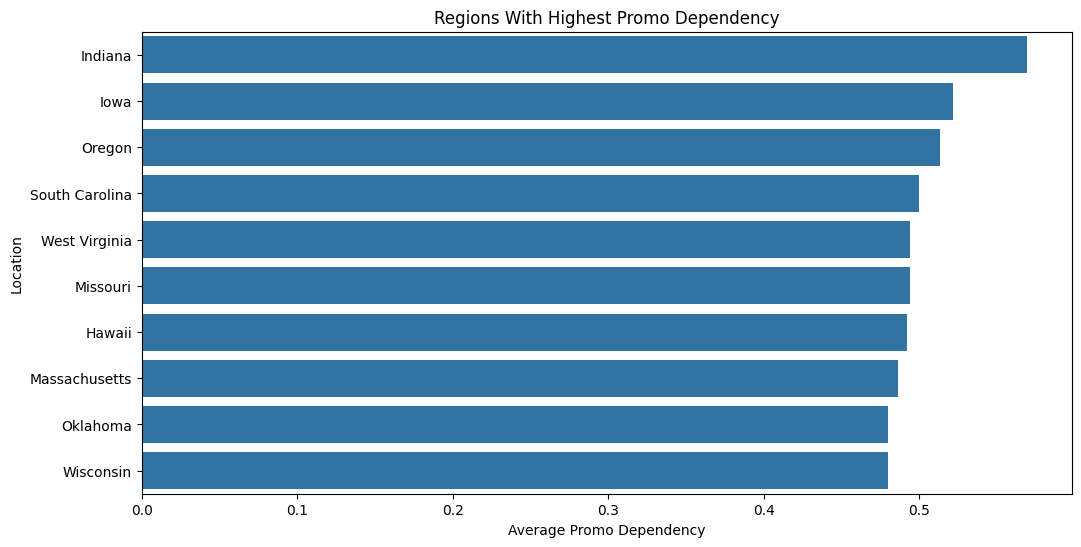

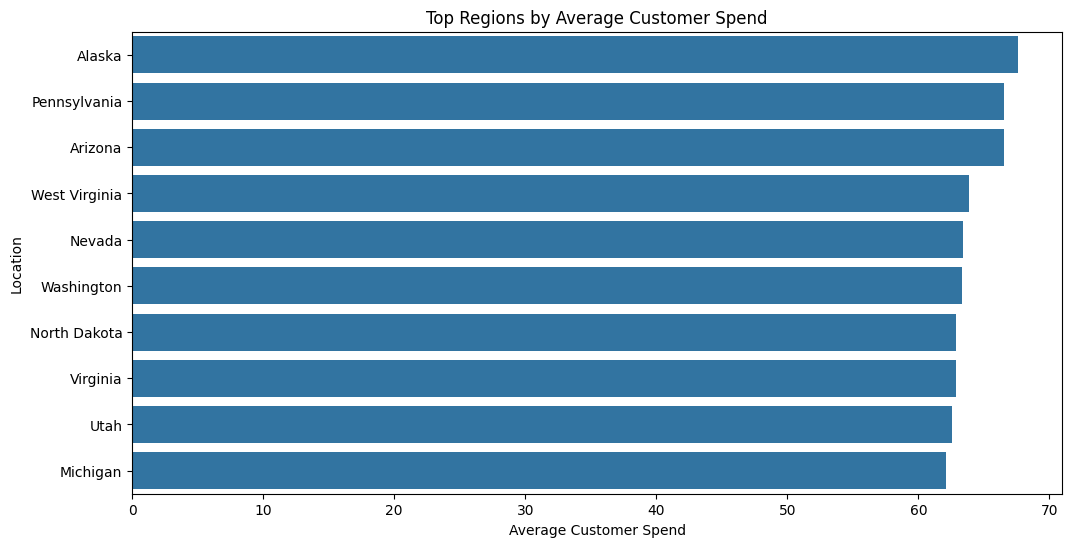

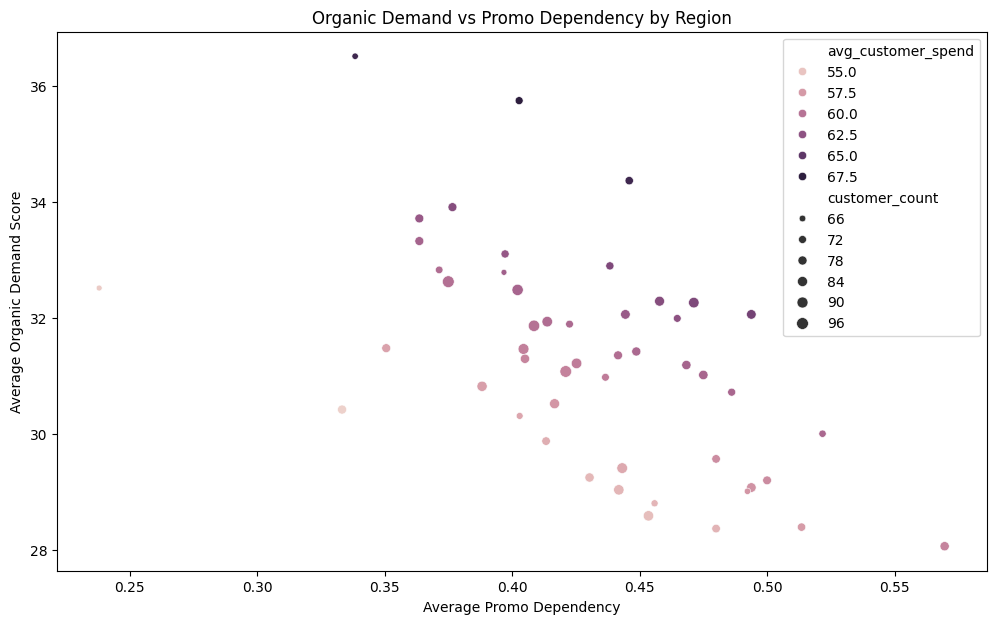

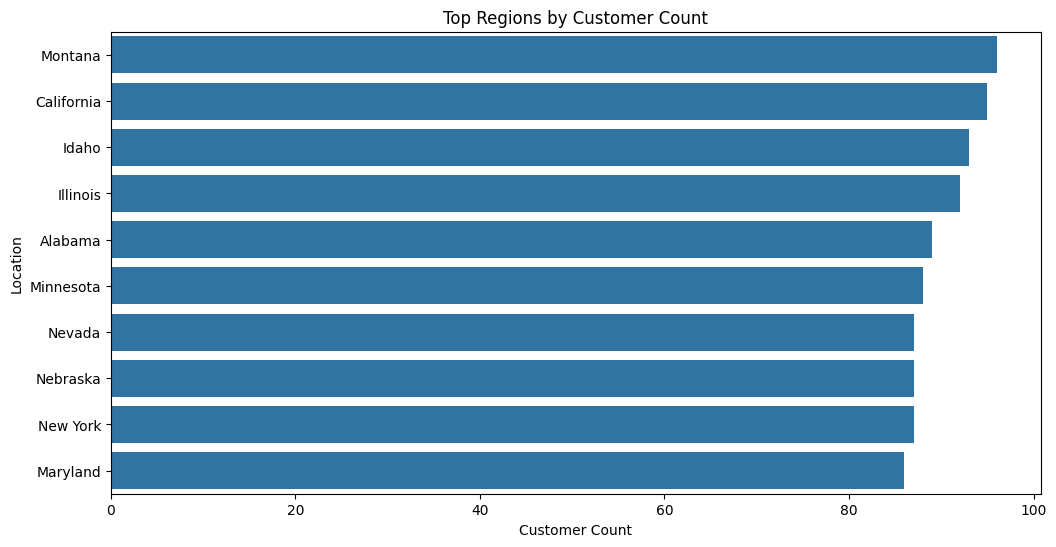

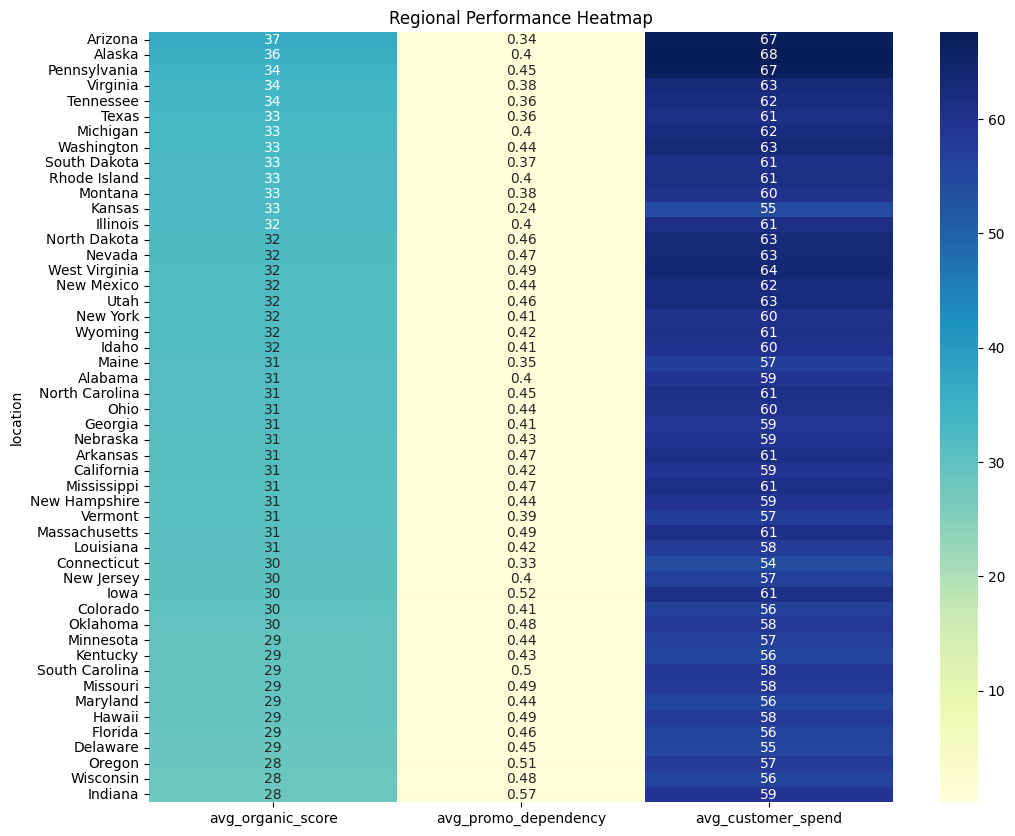

In [44]:
#Chart 1 : Top Regions by Organic Demand
top_geo = geo_analysis.sort_values(
    by='avg_organic_score',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_geo,
    x='avg_organic_score',
    y='location'
)
plt.title("Top Regions by Organic Demand Score")
plt.xlabel("Average Organic Demand Score")
plt.ylabel("Location")
plt.show()


#Chart 2 : Regions With Highest Promo Dependency
promo_geo = geo_analysis.sort_values(
    by='avg_promo_dependency',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=promo_geo,
    x='avg_promo_dependency',
    y='location'
)
plt.title("Regions With Highest Promo Dependency")
plt.xlabel("Average Promo Dependency")
plt.ylabel("Location")
plt.show()


#Chart 3 : Average Customer Spend By Region
spend_geo = geo_analysis.sort_values(
    by='avg_customer_spend',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=spend_geo,
    x='avg_customer_spend',
    y='location'
)
plt.title("Top Regions by Average Customer Spend")
plt.xlabel("Average Customer Spend")
plt.ylabel("Location")
plt.show()


#Chart 4 : Organic Demand vs Promo Dependency
plt.figure(figsize=(12,7))
sns.scatterplot(
    data=geo_analysis,
    x='avg_promo_dependency',
    y='avg_organic_score',
    size='customer_count',
    hue='avg_customer_spend'
)

plt.title("Organic Demand vs Promo Dependency by Region")
plt.xlabel("Average Promo Dependency")
plt.ylabel("Average Organic Demand Score")
plt.show()


#Chart 5 : Customer Distribution By Region
customer_geo = geo_analysis.sort_values(
    by='customer_count',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=customer_geo,
    x='customer_count',
    y='location'
)
plt.title("Top Regions by Customer Count")
plt.xlabel("Customer Count")
plt.ylabel("Location")
plt.show()


#Chart 6 : Regional Performance Heatmap
heatmap_data = geo_analysis[
    [
        'location',
        'avg_organic_score',
        'avg_promo_dependency',
        'avg_customer_spend'
    ]
]

heatmap_data = heatmap_data.set_index('location')
plt.figure(figsize=(12,10))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)
plt.title("Regional Performance Heatmap")
plt.show()

##FINAL FEATURE TABLE

In [45]:
customer_df.head()

,customer_id,total_spend,avg_spend,max_spend,previous_purchases,avg_review_rating,age,gender,location,subscription_status,preferred_payment,preferred_shipping,category_diversity,product_diversity,discount_orders,promo_orders,purchase_frequency,aov,total_transactions,repeat_customer_flag,promo_dependency_score,satisfaction_flag,spend_score,frequency_score,purchase_history_score,value_score,value_tier,organic_spend,organic_spend_ratio,avg_discount_spend,avg_non_discount_spend,discount_sensitivity_score,high_margin_customer,organic_demand_score,risk_flag,loyalty_score_1,review_score_normalized,low_promo_score,loyalty_score_2,loyalty1_group,loyalty2_group,customer_segment,strategic_segment
0,1,53,53.0,53,14,3.1,55,Male,Kentucky,Yes,Venmo,Express,1,1,1,1,Fortnightly,3.79,1,0,1.0,Unsatisfied,0.4125,0.0,0.265306,25.93,Silver,0.0,0.0,53.0,0.0,1.0,No,16.5,High Risk,10.61,0.24,0.0,23.7,Low,Low,Discount Hunters,Promo Locked
1,2,64,64.0,64,2,3.1,19,Male,Maine,Yes,Cash,Express,1,1,1,1,Fortnightly,32.00,1,0,1.0,Unsatisfied,0.5500,0.0,0.020408,27.91,Silver,0.0,0.0,64.0,0.0,1.0,No,22.0,High Risk,0.82,0.24,0.0,29.2,Low,Low,Discount Hunters,Promo Locked
2,3,73,73.0,73,23,3.1,50,Male,Massachusetts,Yes,Credit Card,Free Shipping,1,1,1,1,Weekly,3.17,1,0,1.0,Unsatisfied,0.6625,0.0,0.448980,42.10,Gold,0.0,0.0,73.0,0.0,1.0,No,26.5,High Risk,17.96,0.24,0.0,33.7,Medium,Low,Discount Hunters,Promo Locked
3,4,90,90.0,90,49,3.5,21,Male,Rhode Island,Yes,Paypal,Next Day Air,1,1,1,1,Weekly,1.84,1,0,1.0,Unsatisfied,0.8750,0.0,0.979592,63.34,Platinum,0.0,0.0,90.0,0.0,1.0,No,35.0,Low Risk,39.18,0.40,0.0,47.0,High,Medium,Discount Hunters,Promo Locked
4,5,49,49.0,49,31,2.7,45,Male,Oregon,Yes,Paypal,Free Shipping,1,1,1,1,Annually,1.58,1,0,1.0,Unsatisfied,0.3625,0.0,0.612245,30.37,Silver,0.0,0.0,49.0,0.0,1.0,No,14.5,High Risk,24.49,0.08,0.0,16.9,Medium,Low,Discount Hunters,Promo Locked


##EXPORT FINAL DATASET

In [46]:
customer_df.to_csv(
    "customer_features.csv",
    index=False
)
print("customer_features.csv exported successfully!")

customer_features.csv exported successfully!


In [47]:
customer_df.shape

(3900, 43)

### CLEANING DATA AND INCLUDING CATEGORY AND SEASON

In [48]:
import pandas as pd
df = pd.read_csv("customer_features.csv")
print(df.columns.tolist())

['customer_id', 'total_spend', 'avg_spend', 'max_spend', 'previous_purchases', 'avg_review_rating', 'age', 'gender', 'location', 'subscription_status', 'preferred_payment', 'preferred_shipping', 'category_diversity', 'product_diversity', 'discount_orders', 'promo_orders', 'purchase_frequency', 'aov', 'total_transactions', 'repeat_customer_flag', 'promo_dependency_score', 'satisfaction_flag', 'spend_score', 'frequency_score', 'purchase_history_score', 'value_score', 'value_tier', 'organic_spend', 'organic_spend_ratio', 'avg_discount_spend', 'avg_non_discount_spend', 'discount_sensitivity_score', 'high_margin_customer', 'organic_demand_score', 'risk_flag', 'loyalty_score_1', 'review_score_normalized', 'low_promo_score', 'loyalty_score_2', 'loyalty1_group', 'loyalty2_group', 'customer_segment', 'strategic_segment']


In [49]:
other_data = pd.read_csv("/content/SQL_Data.csv")
df["Category"] = other_data["Category"]
df["Season"] = other_data["Season"]

In [50]:
print(df.dtypes)

customer_id                     int64
total_spend                     int64
avg_spend                     float64
max_spend                       int64
previous_purchases              int64
avg_review_rating             float64
age                             int64
gender                         object
location                       object
subscription_status            object
preferred_payment              object
preferred_shipping             object
category_diversity              int64
product_diversity               int64
discount_orders                 int64
promo_orders                    int64
purchase_frequency             object
aov                           float64
total_transactions              int64
repeat_customer_flag            int64
promo_dependency_score        float64
satisfaction_flag              object
spend_score                   float64
frequency_score               float64
purchase_history_score        float64
value_score                   float64
value_tier  

In [51]:
df["avg_review_rating"].isnull().sum()

np.int64(37)

In [52]:
df["avg_review_rating"].apply(type).value_counts()

,count
avg_review_rating,
<class 'float'>,3900


In [53]:
df[df["avg_review_rating"].isnull()]

,customer_id,total_spend,avg_spend,max_spend,previous_purchases,avg_review_rating,age,gender,location,subscription_status,preferred_payment,preferred_shipping,category_diversity,product_diversity,discount_orders,promo_orders,purchase_frequency,aov,total_transactions,repeat_customer_flag,promo_dependency_score,satisfaction_flag,spend_score,frequency_score,purchase_history_score,value_score,value_tier,organic_spend,organic_spend_ratio,avg_discount_spend,avg_non_discount_spend,discount_sensitivity_score,high_margin_customer,organic_demand_score,risk_flag,loyalty_score_1,review_score_normalized,low_promo_score,loyalty_score_2,loyalty1_group,loyalty2_group,customer_segment,strategic_segment,Category,Season
38,39,37,37.0,37,44,NaN,29,Male,Florida,Yes,Venmo,2-Day Shipping,1,1,1,1,Every 3 Months,0.84,1,0,1.0,Unsatisfied,0.2125,0.0,0.877551,28.18,Silver,0.0,0.0,37.0,0.0,1.0,No,8.5,Low Risk,35.10,NaN,0.0,NaN,High,NaN,Discount Hunters,Promo Locked,Clothing,Winter
50,51,28,28.0,28,39,NaN,49,Male,Maryland,Yes,Debit Card,Store Pickup,1,1,1,1,Bi-Weekly,0.72,1,0,1.0,Unsatisfied,0.1000,0.0,0.775510,20.51,Bronze,0.0,0.0,28.0,0.0,1.0,No,4.0,Low Risk,31.02,NaN,0.0,NaN,High,NaN,Discount Hunters,Promo Locked,Clothing,Spring
80,81,72,72.0,72,24,NaN,19,Male,New York,Yes,Credit Card,Store Pickup,1,1,1,1,Every 3 Months,3.00,1,0,1.0,Unsatisfied,0.6500,0.0,0.469388,41.89,Gold,0.0,0.0,72.0,0.0,1.0,No,26.0,Low Risk,18.78,NaN,0.0,NaN,Medium,NaN,Discount Hunters,Promo Locked,Footwear,Summer
96,97,73,73.0,73,43,NaN,32,Male,Delaware,Yes,Venmo,Express,1,1,1,1,Every 3 Months,1.70,1,0,1.0,Unsatisfied,0.6625,0.0,0.857143,50.27,Platinum,0.0,0.0,73.0,0.0,1.0,No,26.5,Low Risk,34.29,NaN,0.0,NaN,High,NaN,Discount Hunters,Promo Locked,Accessories,Spring
262,263,40,40.0,40,6,NaN,37,Male,Hawaii,Yes,Debit Card,Next Day Air,1,1,1,1,Annually,6.67,1,0,1.0,Unsatisfied,0.2500,0.0,0.102041,14.54,Bronze,0.0,0.0,40.0,0.0,1.0,No,10.0,Low Risk,4.08,NaN,0.0,NaN,Low,NaN,Discount Hunters,Promo Locked,Clothing,Summer
330,331,51,51.0,51,43,NaN,46,Male,North Dakota,Yes,Venmo,Express,1,1,1,1,Bi-Weekly,1.19,1,0,1.0,Unsatisfied,0.3875,0.0,0.857143,36.52,Gold,0.0,0.0,51.0,0.0,1.0,No,15.5,Low Risk,34.29,NaN,0.0,NaN,High,NaN,Discount Hunters,Promo Locked,Clothing,Winter
356,357,80,80.0,80,27,NaN,56,Male,Nevada,Yes,Cash,Standard,1,1,1,1,Weekly,2.96,1,0,1.0,Unsatisfied,0.7500,0.0,0.530612,48.11,Platinum,0.0,0.0,80.0,0.0,1.0,No,30.0,Low Risk,21.22,NaN,0.0,NaN,Medium,NaN,Discount Hunters,Promo Locked,Clothing,Spring
383,384,77,77.0,77,6,NaN,50,Male,West Virginia,Yes,Paypal,Standard,1,1,1,1,Quarterly,12.83,1,0,1.0,Unsatisfied,0.7125,0.0,0.102041,37.67,Gold,0.0,0.0,77.0,0.0,1.0,No,28.5,Low Risk,4.08,NaN,0.0,NaN,Low,NaN,Discount Hunters,Promo Locked,Accessories,Fall
419,420,91,91.0,91,14,NaN,53,Male,Utah,Yes,Credit Card,Free Shipping,1,1,1,1,Every 3 Months,6.50,1,0,1.0,Unsatisfied,0.8875,0.0,0.265306,49.68,Platinum,0.0,0.0,91.0,0.0,1.0,No,35.5,Low Risk,10.61,NaN,0.0,NaN,Low,NaN,Discount Hunters,Promo Locked,Clothing,Winter
442,443,69,69.0,69,31,NaN,29,Male,Michigan,Yes,Credit Card,Store Pickup,1,1,1,1,Quarterly,2.23,1,0,1.0,Unsatisfied,0.6125,0.0,0.612245,42.87,Gold,0.0,0.0,69.0,0.0,1.0,No,24.5,Low Risk,24.49,NaN,0.0,NaN,Medium,NaN,Discount Hunters,Promo Locked,Accessories,Fall


In [54]:
df["avg_review_rating"] = df["avg_review_rating"].fillna(
    df["avg_review_rating"].mean()
)

In [55]:
df[df["avg_review_rating"].isnull()]

,customer_id,total_spend,avg_spend,max_spend,previous_purchases,avg_review_rating,age,gender,location,subscription_status,preferred_payment,preferred_shipping,category_diversity,product_diversity,discount_orders,promo_orders,purchase_frequency,aov,total_transactions,repeat_customer_flag,promo_dependency_score,satisfaction_flag,spend_score,frequency_score,purchase_history_score,value_score,value_tier,organic_spend,organic_spend_ratio,avg_discount_spend,avg_non_discount_spend,discount_sensitivity_score,high_margin_customer,organic_demand_score,risk_flag,loyalty_score_1,review_score_normalized,low_promo_score,loyalty_score_2,loyalty1_group,loyalty2_group,customer_segment,strategic_segment,Category,Season


##FINAL EXPORT

In [56]:
customer_df.to_csv(
    "cleaned_data.csv",
    index=False
)
print("cleaned_data.csv exported successfully!")

cleaned_data.csv exported successfully!
